# ML Homework 2 Guide

1. Save a copy of this ipynb file in your GoogleDrive or PC.
2. Edit the name of this code from "HW1.ipynb" to "HW1_(your name).ipynb"
3. Fill out the code cells below according to descriptions.
4. Save and upload to BrightSpace. (DO NOT clear the outputs of your code)
5. Convert the .ipynb file to PDF file and upload together

# [HW 2-1] Feature Extraction

Extract features from EXAMPLE DATASET according to following instructions:

1. Load 60 normal data and 60 abnormal data (Normal_1 ~ 60, Abnormal_1 ~ 60)
2. Extract features from acceleration and voltage signal (EXCLUDING current)
3. Extract 3 types of feature: Max, Min, Mean
4. Extract features from ONLY FREQUENCY (NOT Time) domains (WT coefficients)
5. Set the MOTHER WAVELET to 'sym3'
6. Set the wavelet decomposition level to 4


* Number of features: 3 features * 2 sensors * 4 WT levels = 24 features (per data)

* Refer to ML3_Code1

In [2]:

import pandas as pd
import numpy as np
import scipy.stats as sp
import pywt

from google.colab import drive
drive.mount('/content/drive')

# Declare the size of feature dataset
NoOfData    = 60
NoOfSensor  = 2
NoOfFeature = 3

# Load raw dataset (120 files)
for i in range(NoOfData):

  temp_path1 = f'https://github.com/purduelamm/purdue_me597_iiot/blob/main/ml_tutorial/Dataset/Normal_{i+1}?raw=true'   # File path of temporary normal data
  temp_path2 = f'https://github.com/purduelamm/purdue_me597_iiot/blob/main/ml_tutorial/Dataset/Abnormal_{i+1}?raw=true' # File path of temporary abnormal data

  exec(f"Normal_{i+1}   = pd.read_csv(temp_path1 , sep=',' , header=None)")
  exec(f"Abnormal_{i+1} = pd.read_csv(temp_path2 , sep=',' , header=None)")


# Set wavelet transform options
MotherWavelet = pywt.Wavelet('sym3') # Create a sym3 mother wavelet object for wavelet transformation
Level        = 4

# Create empty(0) arrays for normal/abnormal feature dataset
FreqFeature_Normal   = np.zeros(shape=(NoOfSensor*NoOfFeature*Level , NoOfData))
FreqFeature_Abnormal = np.zeros(shape=(NoOfSensor*NoOfFeature*Level , NoOfData))

# Frequency domain feature extraction

for i in range(NoOfData):

  exec(f"temp_data1 = Normal_{i+1}.iloc[:,1:]")
  exec(f"temp_data2 = Abnormal_{i+1}.iloc[:,1:]")
  # Walvelet decomposition
  Coef1 = pywt.wavedec(temp_data1, MotherWavelet, level=Level, axis=0)
  Coef2 = pywt.wavedec(temp_data2, MotherWavelet, level=Level, axis=0)
  for j in range(NoOfSensor):

      for k in np.arange(Level):
          coef1 = Coef1[Level-k]
          coef2 = Coef2[Level-k]

          # Normal features
          FreqFeature_Normal[ j*NoOfFeature*Level+k*NoOfFeature , i] = np.max(coef1[:,j])
          FreqFeature_Normal[ j*NoOfFeature*Level+k*NoOfFeature , i] = np.min(coef1[:,j])
          FreqFeature_Normal[  j*NoOfFeature*Level+k*NoOfFeature, i] = np.mean(coef1[:,j])
          # Abnormal features
          FreqFeature_Abnormal[ j*NoOfFeature*Level+k*NoOfFeature , i] = np.max(coef2[:,j])
          FreqFeature_Abnormal[  j*NoOfFeature*Level+k*NoOfFeature, i] = np.min(coef2[:,j])
          FreqFeature_Abnormal[  j*NoOfFeature*Level+k*NoOfFeature, i] = np.mean(coef2[:,j])


# Result
FreqFeature = np.concatenate([FreqFeature_Normal, FreqFeature_Abnormal] , axis=1)
FreqFeature.shape

Mounted at /content/drive


(24, 120)

# [HW2-2]

Reduce demension of the above featureset (12-D) to 2-D based on t-SNE and Visualize it.

* Don't need to select features
* Refer to ML4_Code2

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 120 samples in 0.001s...
[t-SNE] Computed neighbors for 120 samples in 0.004s...
[t-SNE] Computed conditional probabilities for sample 120 / 120
[t-SNE] Mean sigma: 1.226818
[t-SNE] KL divergence after 250 iterations with early exaggeration: 54.179214
[t-SNE] KL divergence after 500 iterations: 0.391377


 t-SNE done! Time elapsed: 0.3780844211578369 seconds




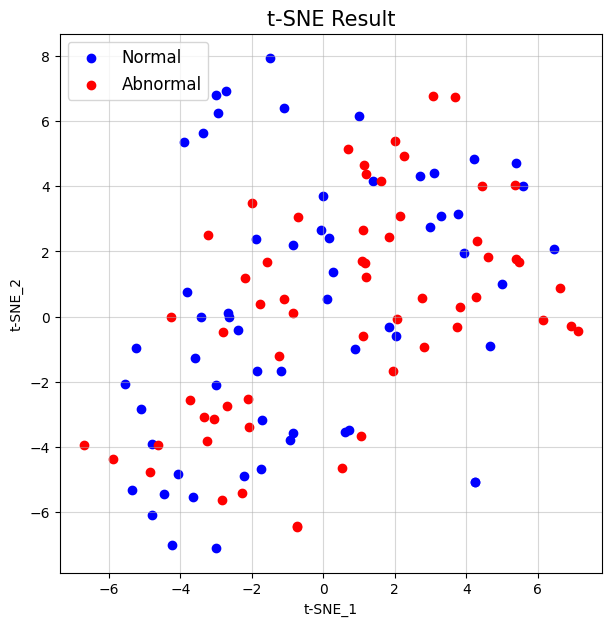

In [16]:
# Data Standardization
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.manifold import TSNE  # Import a package for t-SNE
import time
import matplotlib.pyplot as plt
Feature = FreqFeature.T
Feature_std=StandardScaler().fit_transform(Feature)
pd.DataFrame(Feature_std)

# t-SNE Implementation

dim          = 2
time_start   = time.time()
tsne         = TSNE(n_components=dim, verbose=1, perplexity=30, n_iter=500, random_state=1)
                                              # 'perplexity' is generally set to a value between 5 and 50.
tsne_results = tsne.fit_transform(Feature_std)

print( '\n\n t-SNE done! Time elapsed: {} seconds\n\n'.format(time.time() - time_start ))


# Visualization of t-SNE Result


NoOfData = int(Feature_std.shape[0]/2)

plt.figure(figsize=(7,7))

plt.scatter(tsne_results[:NoOfData,0], tsne_results[:NoOfData,1], marker='o', label='Normal', c='b')
plt.scatter(tsne_results[NoOfData:,0], tsne_results[NoOfData:,1], marker='o', label='Abnormal', c='r')
plt.title('t-SNE Result', fontsize=15)
plt.grid(alpha=0.5)
plt.legend(fontsize=12)
plt.xlabel('t-SNE_1')
plt.ylabel('t-SNE_2')

plt.show()



## ML3 and ML4 Summary and Deliverables

Answer the following questions for your achievements

### Q1. Please summarize ML3 and ML4.

---

ML3: Learned statistical analysis and hypothesis testing using p-values to evaluate whether features can distinguish normal and abnormal conditions.
ML4: Learned feature extraction using wavelet transform and visualized normal and abnormal data using PCA and t-SNE for dimensionality reduction.

---

### Q2. What skills did you have to develop to accomplish this project?

---

I developed skills in statistical analysis, feature extraction, dimensionality reduction, and data visualization using Python. I also improved my ability to interpret machine learning results through p-value analysis, PCA, and t-SNE.

---

### Q3. What aspects of this project were the most beneficial for your learning?

---
The most beneficial aspect was learning how to analyze sensor data and evaluate feature effectiveness using statistical methods and dimensionality reduction techniques. It helped me better understand the data preprocessing process for machine learning.

---

### Q4. What challenges did you encounter in completing the project?

---

Understanding the wavelet transform and selecting the appropriate decomposition level and mother wavelet were the most challenging parts.

---

### Q5. How did you overcome the challenges or remedy the problems encountered?

---

I overcame the challenges by reviewing the theory of wavelet transform, experimenting with different decomposition levels and mother wavelets, and comparing the feature extraction results to select the most suitable settings.

---